## Multi-protocol CNN Raw CSI Experiments

This notebook runs the fixed-capacity CNN across block, LOVO, and cross-session protocols with one independent run per configured seed.

In [1]:
from __future__ import annotations

import pandas as pd
import torch

from utils.config import (
    ANCHOR_GROUPS,
    ARCHITECTURE,
    BANDS_TO_RUN,
    DATA_DIR,
    DEFAULT_CNN_PARAMS,
    DEFAULT_OVERLAP_SIZE,
    DEFAULT_WINDOW_SIZE,
    EXPECTED_ANCHORS,
    EXPECTED_SUBCARRIERS,
    SEEDS,
)
from utils.DL.dl_pipeline import (
    create_position_label_encoder,
    get_cache_path,
    get_results_path,
    prepare_dl_data,
    print_torch_environment,
    run_dl_experiments,
    show_dl_results,
)
from utils.ML.ml_pipeline import (
    best_confusion_predictions,
    lovo_aggregated_analysis_table,
    master_results_table,
    per_room_position_accuracy_table,
)
from utils.plots import (
    plot_band_error_cdf,
    plot_block_vs_lovo_position_accuracy,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_lovo_fold_spread,
    plot_model_band_error_boxplot,
    plot_position_confusion_by_true_room,
)


### Configuration

In [2]:
CALIBRATION_MODE = "rssi"    # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "empty_baseline",  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_session"

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": DEFAULT_WINDOW_SIZE,
    "overlap_size": DEFAULT_OVERLAP_SIZE,
    "require_all_esps": False,
}

BLOCK_COUNT = 10
TEST_SIZE = 0.30
VALIDATION_SIZE = 0.15
RANDOM_STATE = 42
FORCE_RETRAIN = False
SPLIT_MODES = ("block", "lovo")

ANALYSIS_SEED = SEEDS[0]
ANALYSIS_MODEL = "CNN_room" if ARCHITECTURE == "room_stacked" else "CNN"
ANALYSIS_BANDS = ("Fusion",) if ARCHITECTURE == "room_stacked" else BANDS_TO_RUN
CONFUSION_DATASET = "Fusion"
CONFUSION_SPLIT = "block" if "block" in SPLIT_MODES else SPLIT_MODES[0]
SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False

CNN_PARAMS = {
    **DEFAULT_CNN_PARAMS,
    "model_label": "CNN",
    "epochs": 70,
    "patience": 15,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "validation_size": VALIDATION_SIZE,
    "n_blocks": BLOCK_COUNT,
    "anchor_groups": ANCHOR_GROUPS,
    "torch_version": torch.__version__,
}

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)

feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path()
plots_dir = results_dir / "plots"
tables_dir = results_dir / "tables"
for directory in (plots_dir, results_dir / "predictions", tables_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    """Convert a display value to a compact filename-safe slug."""
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")


analysis_plots_dir = (
    plots_dir / f"analysis_{_slugify(ANALYSIS_MODEL)}_seed-{ANALYSIS_SEED}"
)
analysis_plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
print(f"Analysis figures path: {analysis_plots_dir}")


Feature cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
Results path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results
Analysis figures path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42


### Environment

In [3]:
DEVICE = print_torch_environment(require_cuda=True)


torch.__version__: 2.11.0+cu128
torch.version.cuda: 12.8
torch.cuda.get_device_name(0): NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition
torch.cuda.get_device_capability(0): (12, 0)
CUDA matmul smoke test result: [[0.0, 1.0, 2.0, 3.0], [4.0, 5.0, 6.0, 7.0], [8.0, 9.0, 10.0, 11.0], [12.0, 13.0, 14.0, 15.0]] (PASS)


### Data

In [4]:
processed_magnitude_data, feature_dataframes, csv_diagnostics, magnitude_summary = prepare_dl_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
)
display(magnitude_summary.head())


Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19
[Z-0 inventory]
  total Z-0 files found: 171
  Z-0 count per (user, trial):
    (user=01, trial=01): 19
    (user=01, trial=02): 19
    (user=02, trial=01): 19
    (user=03, trial=01): 19
    (user=03, trial=02): 19
    (user=04, trial=01): 19
    (user=05, trial=01): 19
    (user=05, trial=02): 19
    (user=06, trial=01): 19
  breakdown by user / esp / trial:
    user=01 esp=01 trial=01: 1
    user=01 esp=01 trial=02: 1
    user=01 esp=02 trial=01: 1
    user=01 esp=02 trial=02: 1
    user=01 esp=03 trial=01: 1
    user=01 esp=03 trial=02: 1
    user=01 esp=04 trial=01: 1
    user=01 esp=04 trial=02: 1
    user=01 esp=05 trial=01: 1
    user=01 esp=05 trial=02: 1
    user=01 esp=07 trial=01: 1
    user=01 esp=07 trial=02: 1
    user=01 esp=08 trial=01: 1
    user=01 esp=08 trial=02: 1
    user=01 esp=09 trial=01: 1
    user=01 esp=09 trial=02: 1
    user=01 esp=10 trial=01: 1
    user=01 esp=10 trial=02: 1
    user=01 esp=11 tri

,scenario,location,user,esp,trial,samples,subcarriers,normalization,baseline_scope
0,1,C-1,06,16,01,2088,56,empty_baseline,per_session
1,1,C-1,06,15,01,1942,56,empty_baseline,per_session
2,1,C-1,06,09,01,1689,50,empty_baseline,per_session
3,1,C-1,06,07,01,1965,50,empty_baseline,per_session
4,1,C-1,06,04,01,1913,50,empty_baseline,per_session


In [5]:
for band in BANDS_TO_RUN:
    df = feature_dataframes[band]
    print(f"{band}: {df.shape[0]} windows, {df.shape[1]} columns")
    print(f"{band} dataframe hash: {pd.util.hash_pandas_object(df, index=True).sum()}")


2.4 GHz: 13588 windows, 2708 columns
2.4 GHz dataframe hash: 11876030231112758796
5 GHz: 14478 windows, 3368 columns
5 GHz dataframe hash: 1871796993234382690
Fusion: 13568 windows, 6068 columns
Fusion dataframe hash: 18372045827207501857


In [6]:
label_encoder = create_position_label_encoder(
    feature_dataframes,
    results_dir=results_dir,
    expected_classes=52,
)
print(label_encoder.classes_)


[CNN] label classes saved to /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/manifests/cnn_label_classes.json
['A-1' 'A-13' 'A-14' 'A-2' 'A-5' 'B-1' 'B-10' 'B-11' 'B-12' 'B-13' 'B-14'
 'B-2' 'B-5' 'B-8' 'C-1' 'C-10' 'C-11' 'C-14' 'C-2' 'C-3' 'C-4' 'C-5'
 'C-6' 'C-7' 'C-8' 'C-9' 'D-1' 'D-2' 'D-3' 'D-4' 'D-5' 'D-6' 'D-7' 'D-8'
 'E-1' 'E-10' 'E-11' 'E-12' 'E-13' 'E-2' 'E-3' 'E-4' 'E-5' 'E-6' 'E-7'
 'E-8' 'F-10' 'F-11' 'F-12' 'F-13' 'F-5' 'F-8']


### Train And Evaluate

In [7]:
cnn_runs = run_dl_experiments(
    processed_magnitude_data,
    feature_dataframes,
    bands=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
    label_encoder=label_encoder,
    device=DEVICE,
    results_dir=results_dir,
    plots_dir=plots_dir,
    params=CNN_PARAMS,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    expected_subcarriers=EXPECTED_SUBCARRIERS,
    expected_anchors=EXPECTED_ANCHORS,
    architecture=ARCHITECTURE,
    seeds=SEEDS,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    val_size=VALIDATION_SIZE,
    force_retrain=FORCE_RETRAIN,
)



=== Fusion ===
[window arrays] cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/window_arrays/fusion
[window arrays cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/window_arrays/fusion
[window arrays] 2.4 GHz: shape=(13568, 9, 50, 60), dtype=float16
[window arrays] 2.4 GHz anchors: ['esp_01', 'esp_02', 'esp_03', 'esp_04', 'esp_05', 'esp_07', 'esp_08', 'esp_09', 'esp_10']
[window arrays] 5 GHz: shape=(13568, 10, 56, 60), dtype=float16
[window arrays] 5 GHz anchors: ['esp_11', 'esp_12', 'esp_13', 'esp_14', 'esp_15', 'esp_16', 'esp_17', 'esp_18', 'esp_19', 'esp_20']
[room window arrays] padding rows=2, derived from first-conv kernel_size - 1 (3 - 1).
[room window arrays] cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[CNN_room] Fusion/block fold=single epoch 01/70: train_loss=3.8937 train_acc=0.0573 val_loss=3.9063 val_acc=0.0467 seconds=4.4
[CNN_room] Fusion/block fold=single epoch 02/70: train_loss=3.6187 train_acc=0.1229 val_loss=3.6424 val_acc=0.0733 seconds=0.5
[CNN_room] Fusion/block fold=single epoch 03/70: train_loss=3.2351 train_acc=0.1572 val_loss=3.2276 val_acc=0.1533 seconds=0.5
[CNN_room] Fusion/block fold=single epoch 04/70: train_loss=2.9739 train_acc=0.1825 val_loss=2.9753 val_acc=0.1800 seconds=0.5
[CNN_room] Fusion/block fold=single epoch 05/70: train_loss=2.7883 train_acc=0.2148 val_loss=2.8238 val_acc=0.1933 seconds=0.5
[CNN_room] Fusion/block fold=single epoch 06/70: train_loss=2.6502 train_acc=0.2354 val_loss=2.7398 val_acc=0.2267 seconds=0.5
[CNN_room] Fusion/block fold=single epoch 07/70: train_loss=2.5281 train_acc=0.2671 val_loss=2.5881 val_acc=0.2733 seconds=0.5
[CNN_room] Fusion/block fold=single epoch 08/70: train_loss=2.4004 train_acc=0.3037 val_loss=2.4993 val_acc=0.2

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn_room__fusion__block__ebl-session__s42__dc4ee3.parquet
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl__cnn_room__fusion__block__ebl-session__s42__dc4ee3/training_curves.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other code changes.
[DL GPU] run_id=dl__cnn_room__fusion__block__ebl-session__s42__dc4ee3 peak_cuda_memory_bytes=2685729792
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs.csv: 46 row(s)
Seeds: random=43, numpy=43, torch=43
[trial filter] split=block trials=['01'] kept=8889/13568
[protocol] split=block trials_used=['01'] n_train=4934 n_test=1388 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', '05', '06'] test_users=['01', '02', '03', '04', '05', '06']
[trial filter] split=block trials=['01'] kept=4934/4934
[protocol] split=block trial

...

[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn_room__fusion__lovo__ebl-session__s44__5ccebc__fold-05.parquet
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl__cnn_room__fusion__lovo__ebl-session__s44__5ccebc/training_curves__fold-05.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other code changes.
[DL LOVO] held_out_user=06 validation_user=05 (entire user, deterministic rotation)
[CNN_room] Fusion/lovo fold=06 parameters=195636
[DataLoader] device=cuda settings={'batch_size': 256, 'num_workers': 8, 'pin_memory': True, 'persistent_workers': True, 'prefetch_factor': 4}
[DataLoader] device=cuda settings={'batch_size': 256, 'num_workers': 8, 'pin_memory': True, 'persistent_workers': True, 'prefetch_factor': 4}
[DataLoader] device=cuda settings={'batch_size': 256, 'num_workers': 8, 'pin_memory': True, 'persistent_workers': True, 'prefetch_factor': 4}


/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[CNN_room] Fusion/lovo fold=06 epoch 01/70: train_loss=3.7286 train_acc=0.0780 val_loss=3.9653 val_acc=0.0397 seconds=4.2
[CNN_room] Fusion/lovo fold=06 epoch 02/70: train_loss=3.1016 train_acc=0.1585 val_loss=3.7726 val_acc=0.1285 seconds=1.0
[CNN_room] Fusion/lovo fold=06 epoch 03/70: train_loss=2.7539 train_acc=0.2146 val_loss=3.4647 val_acc=0.1474 seconds=1.0
[CNN_room] Fusion/lovo fold=06 epoch 04/70: train_loss=2.5354 train_acc=0.2579 val_loss=3.2323 val_acc=0.1662 seconds=1.0
[CNN_room] Fusion/lovo fold=06 epoch 05/70: train_loss=2.3700 train_acc=0.3049 val_loss=3.2074 val_acc=0.1958 seconds=1.0
[CNN_room] Fusion/lovo fold=06 epoch 06/70: train_loss=2.2221 train_acc=0.3338 val_loss=3.1586 val_acc=0.2127 seconds=1.0
[CNN_room] Fusion/lovo fold=06 epoch 07/70: train_loss=2.0987 train_acc=0.3641 val_loss=3.0340 val_acc=0.2227 seconds=1.0
[CNN_room] Fusion/lovo fold=06 epoch 08/70: train_loss=1.9970 train_acc=0.3898 val_loss=3.0343 val_acc=0.2207 seconds=1.0
[CNN_room] Fusion/lovo f

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn_room__fusion__lovo__ebl-session__s44__5ccebc__fold-06.parquet
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl__cnn_room__fusion__lovo__ebl-session__s44__5ccebc/training_curves__fold-06.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other code changes.
[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn_room__fusion__lovo__ebl-session__s44__5ccebc.parquet
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs_folds.csv: 126 row(s)
[DL LOVO] seed=44 fold mean position_accuracy=0.1241 +/- 0.0414; pooled=0.1253
[DL GPU] run_id=dl__cnn_room__fusion__lovo__ebl-session__s44__5ccebc peak_cuda_memory_bytes=2685729792
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs.csv: 51 row(s)
[DL seeds] mean +/- std across s

In [8]:
cnn_summary, test_accuracy_comparison = show_dl_results(results_dir)
display(cnn_summary)

display(test_accuracy_comparison)


,run_id,timestamp,family,model,band,split,seed,normalization,baseline_scope,window_size,...,p90_distance_error_max,samples_mean,samples_std,samples_min,samples_max,majority_position_accuracy_min,majority_position_accuracy_max,majority_room_accuracy_min,majority_room_accuracy_max,n_test_windows
27,dl__cnn__2_4ghz__block__ebl-session__s42__9b1404,2026-08-31T14:14:51.729210+00:00,dl,cnn,2_4ghz,block,42.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,dl__cnn__2_4ghz__block__ebl-session__s43__a89b5d,2026-08-31T14:15:08.697352+00:00,dl,cnn,2_4ghz,block,43.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,dl__cnn__2_4ghz__block__ebl-session__s44__7b9bf2,2026-08-31T14:15:25.396778+00:00,dl,cnn,2_4ghz,block,44.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,dl__cnn__2_4ghz__lovo__ebl-session__s42__9b1404,2026-08-31T14:16:49.740654+00:00,dl,cnn,2_4ghz,lovo,42.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,dl__cnn__2_4ghz__lovo__ebl-session__s43__a89b5d,2026-08-31T14:18:28.704881+00:00,dl,cnn,2_4ghz,lovo,43.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,dl__cnn__2_4ghz__lovo__ebl-session__s44__7b9bf2,2026-08-31T14:19:53.895224+00:00,dl,cnn,2_4ghz,lovo,44.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,dl__cnn__5ghz__block__ebl-session__s42__9b1404,2026-08-31T14:20:13.667699+00:00,dl,cnn,5ghz,block,42.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,dl__cnn__5ghz__block__ebl-session__s43__a89b5d,2026-08-31T14:20:27.148110+00:00,dl,cnn,5ghz,block,43.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,dl__cnn__5ghz__block__ebl-session__s44__7b9bf2,2026-08-31T14:20:42.347451+00:00,dl,cnn,5ghz,block,44.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,dl__cnn__5ghz__lovo__ebl-session__s42__9b1404,2026-08-31T14:22:35.132229+00:00,dl,cnn,5ghz,lovo,42.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,band,model,seed,position_accuracy,parameter_count
27,2_4ghz,cnn,42.0,0.426724,76020.0
28,2_4ghz,cnn,43.0,0.419540,76020.0
29,2_4ghz,cnn,44.0,0.387931,76020.0
9,2_4ghz,rf,42.0,0.798132,NaN
33,5ghz,cnn,42.0,0.282160,76308.0
34,5ghz,cnn,43.0,0.276092,76308.0
35,5ghz,cnn,44.0,0.286408,76308.0
12,5ghz,rf,42.0,0.803398,NaN
39,fusion,cnn,42.0,0.448847,138708.0
40,fusion,cnn,43.0,0.506484,138708.0


### Analysis Data

In [9]:
expected_analysis_keys = {
    (band, split_mode, ANALYSIS_SEED)
    for band in ANALYSIS_BANDS
    for split_mode in SPLIT_MODES
}
missing_analysis_keys = sorted(expected_analysis_keys - set(cnn_runs))
if missing_analysis_keys:
    raise RuntimeError(f"Missing CNN runs required for analysis: {missing_analysis_keys}")

analysis_prediction_frames = []
analysis_metrics_rows = []
for (band, split_mode, seed), (predictions, metrics, _) in sorted(cnn_runs.items()):
    if seed != ANALYSIS_SEED or band not in ANALYSIS_BANDS or split_mode not in SPLIT_MODES:
        continue
    prediction_frame = predictions.copy()
    prediction_frame["seed"] = seed
    analysis_prediction_frames.append(prediction_frame)
    analysis_metrics_rows.append(
        {
            "model": str(prediction_frame["model"].iloc[0]),
            "dataset": band,
            "split": split_mode,
            "seed": seed,
            **metrics,
        }
    )

all_cnn_predictions = pd.concat(analysis_prediction_frames, ignore_index=True)
cnn_analysis_summary = pd.DataFrame(analysis_metrics_rows)
cnn_master_table = master_results_table(all_cnn_predictions)
cnn_per_room_table = per_room_position_accuracy_table(all_cnn_predictions)

print(f"Analysis model: {ANALYSIS_MODEL} | seed: {ANALYSIS_SEED}")
display(cnn_master_table)
display(cnn_per_room_table)


Analysis model: CNN_room | seed: 42


,model,dataset,split,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,samples
0,CNN_room,Fusion,block,0.483429,0.476288,0.934438,1.388147,1.000000,2.311480,4.000000,1388.0
1,CNN_room,Fusion,lovo,0.121428,0.094236,0.721050,3.689897,3.075001,4.795268,8.345544,8889.0


,model,dataset,split,true_room,samples,position_accuracy
0,CNN_room,Fusion,block,1,906,0.477925
1,CNN_room,Fusion,block,2,266,0.533835
2,CNN_room,Fusion,block,3,216,0.444444
3,CNN_room,Fusion,lovo,1,5794,0.120642
4,CNN_room,Fusion,lovo,2,1700,0.160000
5,CNN_room,Fusion,lovo,3,1395,0.084588


### LOVO Cross-User Analysis

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42/lovo_cnn_room_fold_spread_seed-42.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


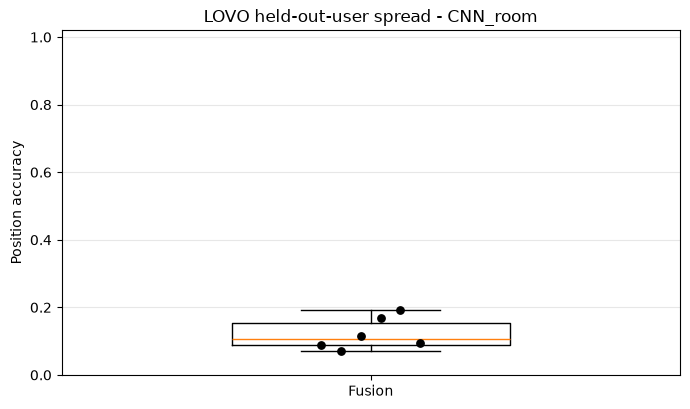

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42/block_vs_lovo_cnn_room_seed-42.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


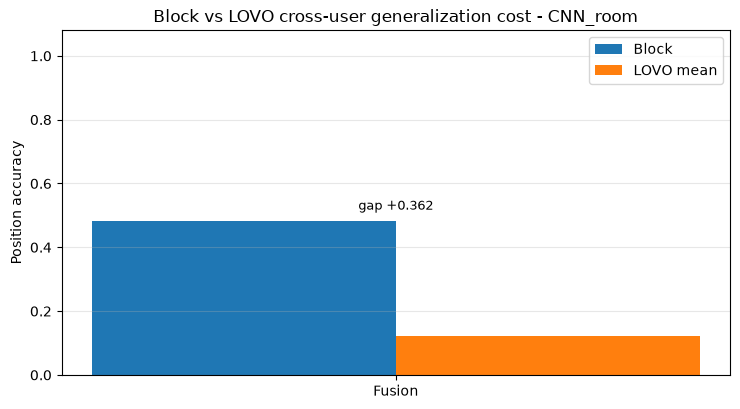

,model,dataset,position_accuracy_mean_std,macro_f1_mean_std,room_accuracy_mean_std,mean_distance_error_mean_std,median_distance_error_mean_std,rmse_distance_error_mean_std,p90_distance_error_mean_std,majority_position_accuracy_mean_std,majority_room_accuracy_mean_std
0,CNN_room,Fusion,0.1214 +/- 0.0486,0.0942 +/- 0.0428,0.7210 +/- 0.0987,3.6899 +/- 0.3774,3.0750 +/- 0.6732,4.7953 +/- 0.2507,8.3455 +/- 0.7705,0.0201 +/- 0.0012,0.6521 +/- 0.0134


,model,dataset,held_out_user,position_accuracy,samples,seed
0,CNN_room,Fusion,01,0.087933,1558,42
1,CNN_room,Fusion,02,0.069454,1411,42
2,CNN_room,Fusion,03,0.116015,1586,42
3,CNN_room,Fusion,04,0.168056,1559,42
4,CNN_room,Fusion,05,0.192463,1486,42
5,CNN_room,Fusion,06,0.094647,1289,42


In [10]:
if "lovo" in SPLIT_MODES:
    lovo_predictions = all_cnn_predictions.loc[
        all_cnn_predictions["split_mode"].eq("lovo")
    ].copy()
    lovo_per_fold = (
        lovo_predictions.assign(
            position_correct=lambda frame: frame["true_position"].eq(
                frame["pred_position"]
            )
        )
        .groupby(["model", "dataset", "held_out_user"], as_index=False, sort=True)
        .agg(
            position_accuracy=("position_correct", "mean"),
            samples=("position_correct", "size"),
        )
    )
    lovo_per_fold["seed"] = ANALYSIS_SEED
    lovo_summary = cnn_analysis_summary.loc[
        cnn_analysis_summary["split"].eq("lovo")
    ].copy()
    lovo_table = lovo_aggregated_analysis_table(lovo_summary)

    plot_lovo_fold_spread(
        lovo_per_fold,
        bands=ANALYSIS_BANDS,
        model=ANALYSIS_MODEL,
        save_path=(
            analysis_plots_dir
            / f"lovo_{_slugify(ANALYSIS_MODEL)}_fold_spread_seed-{ANALYSIS_SEED}.png"
        ),
    )
    plot_block_vs_lovo_position_accuracy(
        cnn_master_table,
        lovo_summary,
        bands=ANALYSIS_BANDS,
        model=ANALYSIS_MODEL,
        save_path=(
            analysis_plots_dir
            / f"block_vs_lovo_{_slugify(ANALYSIS_MODEL)}_seed-{ANALYSIS_SEED}.png"
        ),
    )

    display(lovo_table)
    display(lovo_per_fold)
else:
    print("LOVO analysis skipped because 'lovo' is not in SPLIT_MODES.")


### Analysis Figures

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42/cdf_by_model_fusion.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


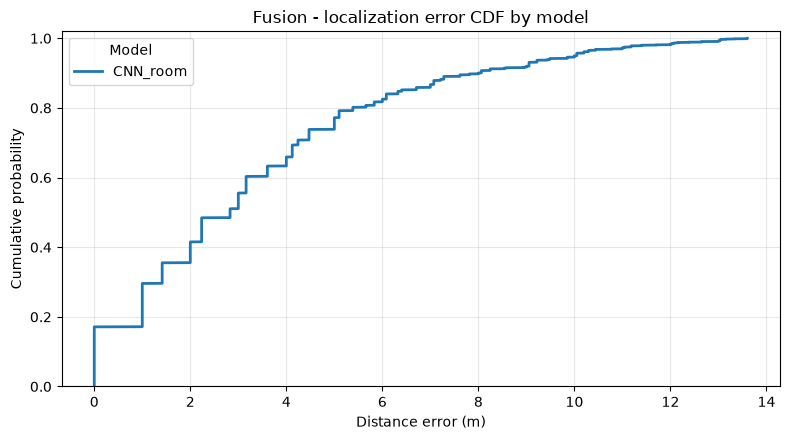

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42/cdf_cnn_room_all-bands_block.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


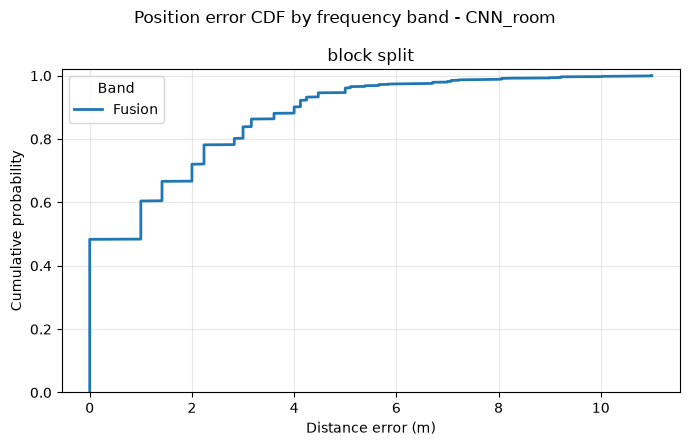

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42/cdf_cnn_room_all-bands_lovo.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


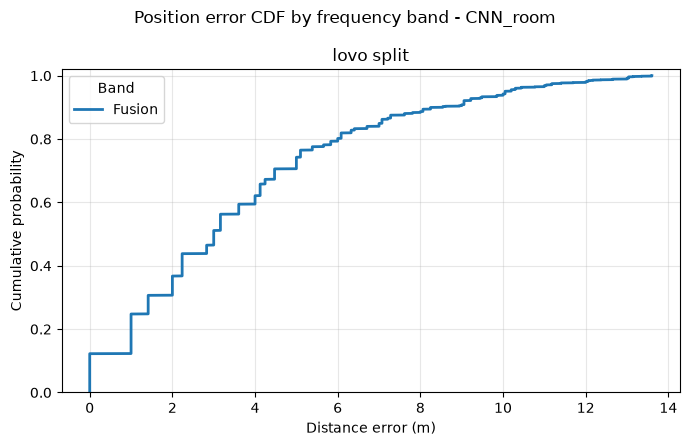

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42/boxplot_cnn_room_band_distance_error.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


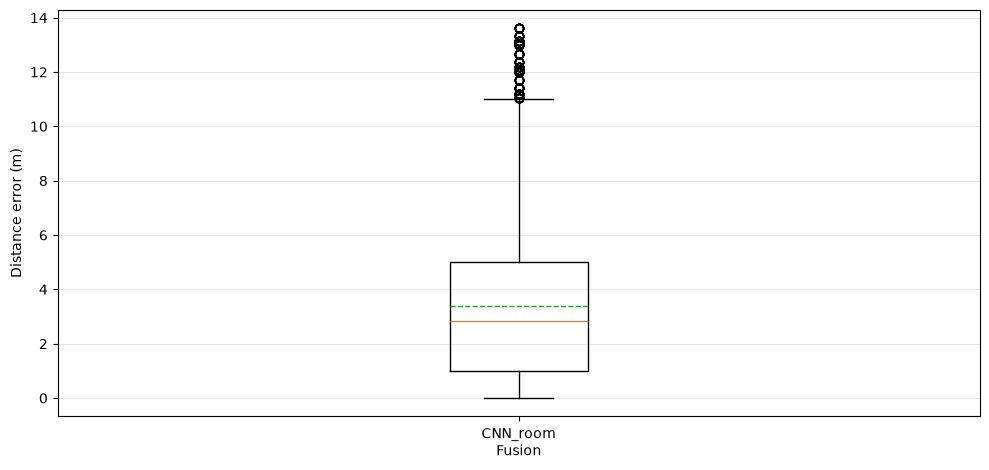

In [11]:
if SHOW_CDF_BY_BAND:
    for band in ANALYSIS_BANDS:
        plot_localization_error_cdf_by_model(
            all_cnn_predictions,
            dataset=band,
            save_path=analysis_plots_dir / f"cdf_by_model_{_slugify(band)}.png",
        )

if SHOW_CDF_BY_MODEL:
    plot_band_error_cdf(
        all_cnn_predictions,
        model_label=ANALYSIS_MODEL,
        split_modes=SPLIT_MODES,
        band_order=ANALYSIS_BANDS,
        save_path=analysis_plots_dir,
    )

if SHOW_BOXPLOT:
    plot_model_band_error_boxplot(
        all_cnn_predictions,
        models=(ANALYSIS_MODEL,),
        bands=ANALYSIS_BANDS,
        save_path=(
            analysis_plots_dir
            / f"boxplot_{_slugify(ANALYSIS_MODEL)}_band_distance_error.png"
        ),
    )


### Confusion Matrix and Floor Plan

Confusion/floor-plan model: CNN_room on Fusion (block, seed 42)


[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42/floor_plan_fusion_cnn_room_block_seed-42.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


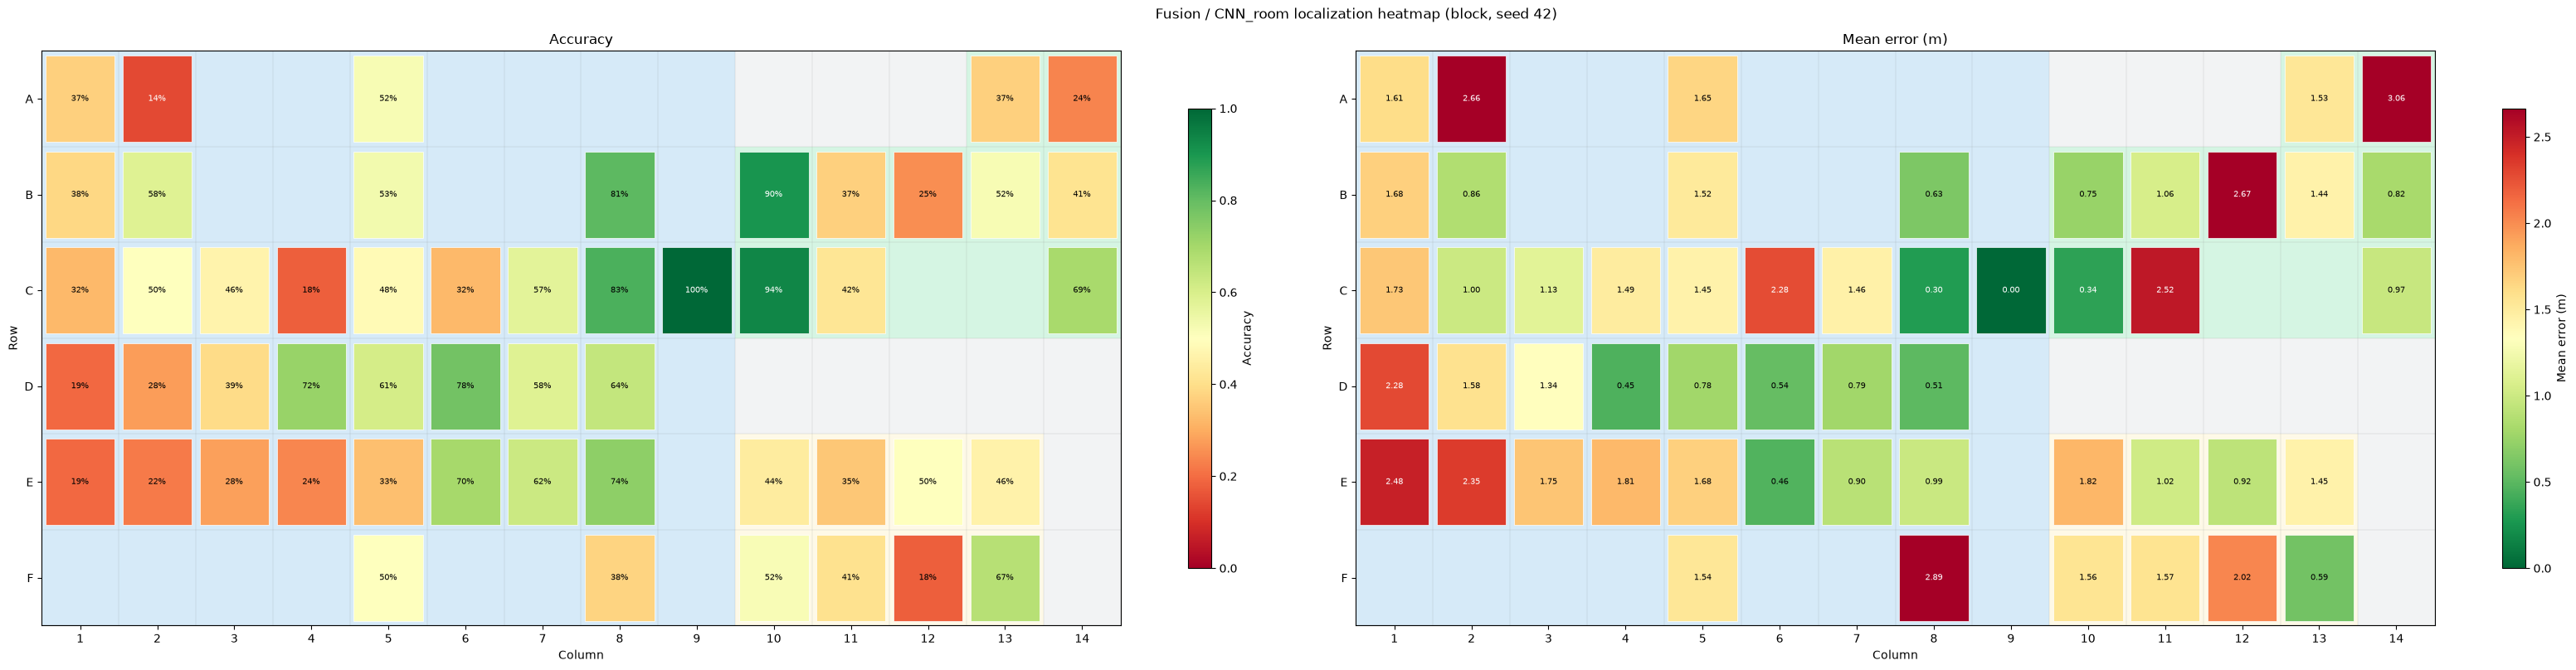

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_room_seed-42/confusion_fusion_cnn_room_block_seed-42.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


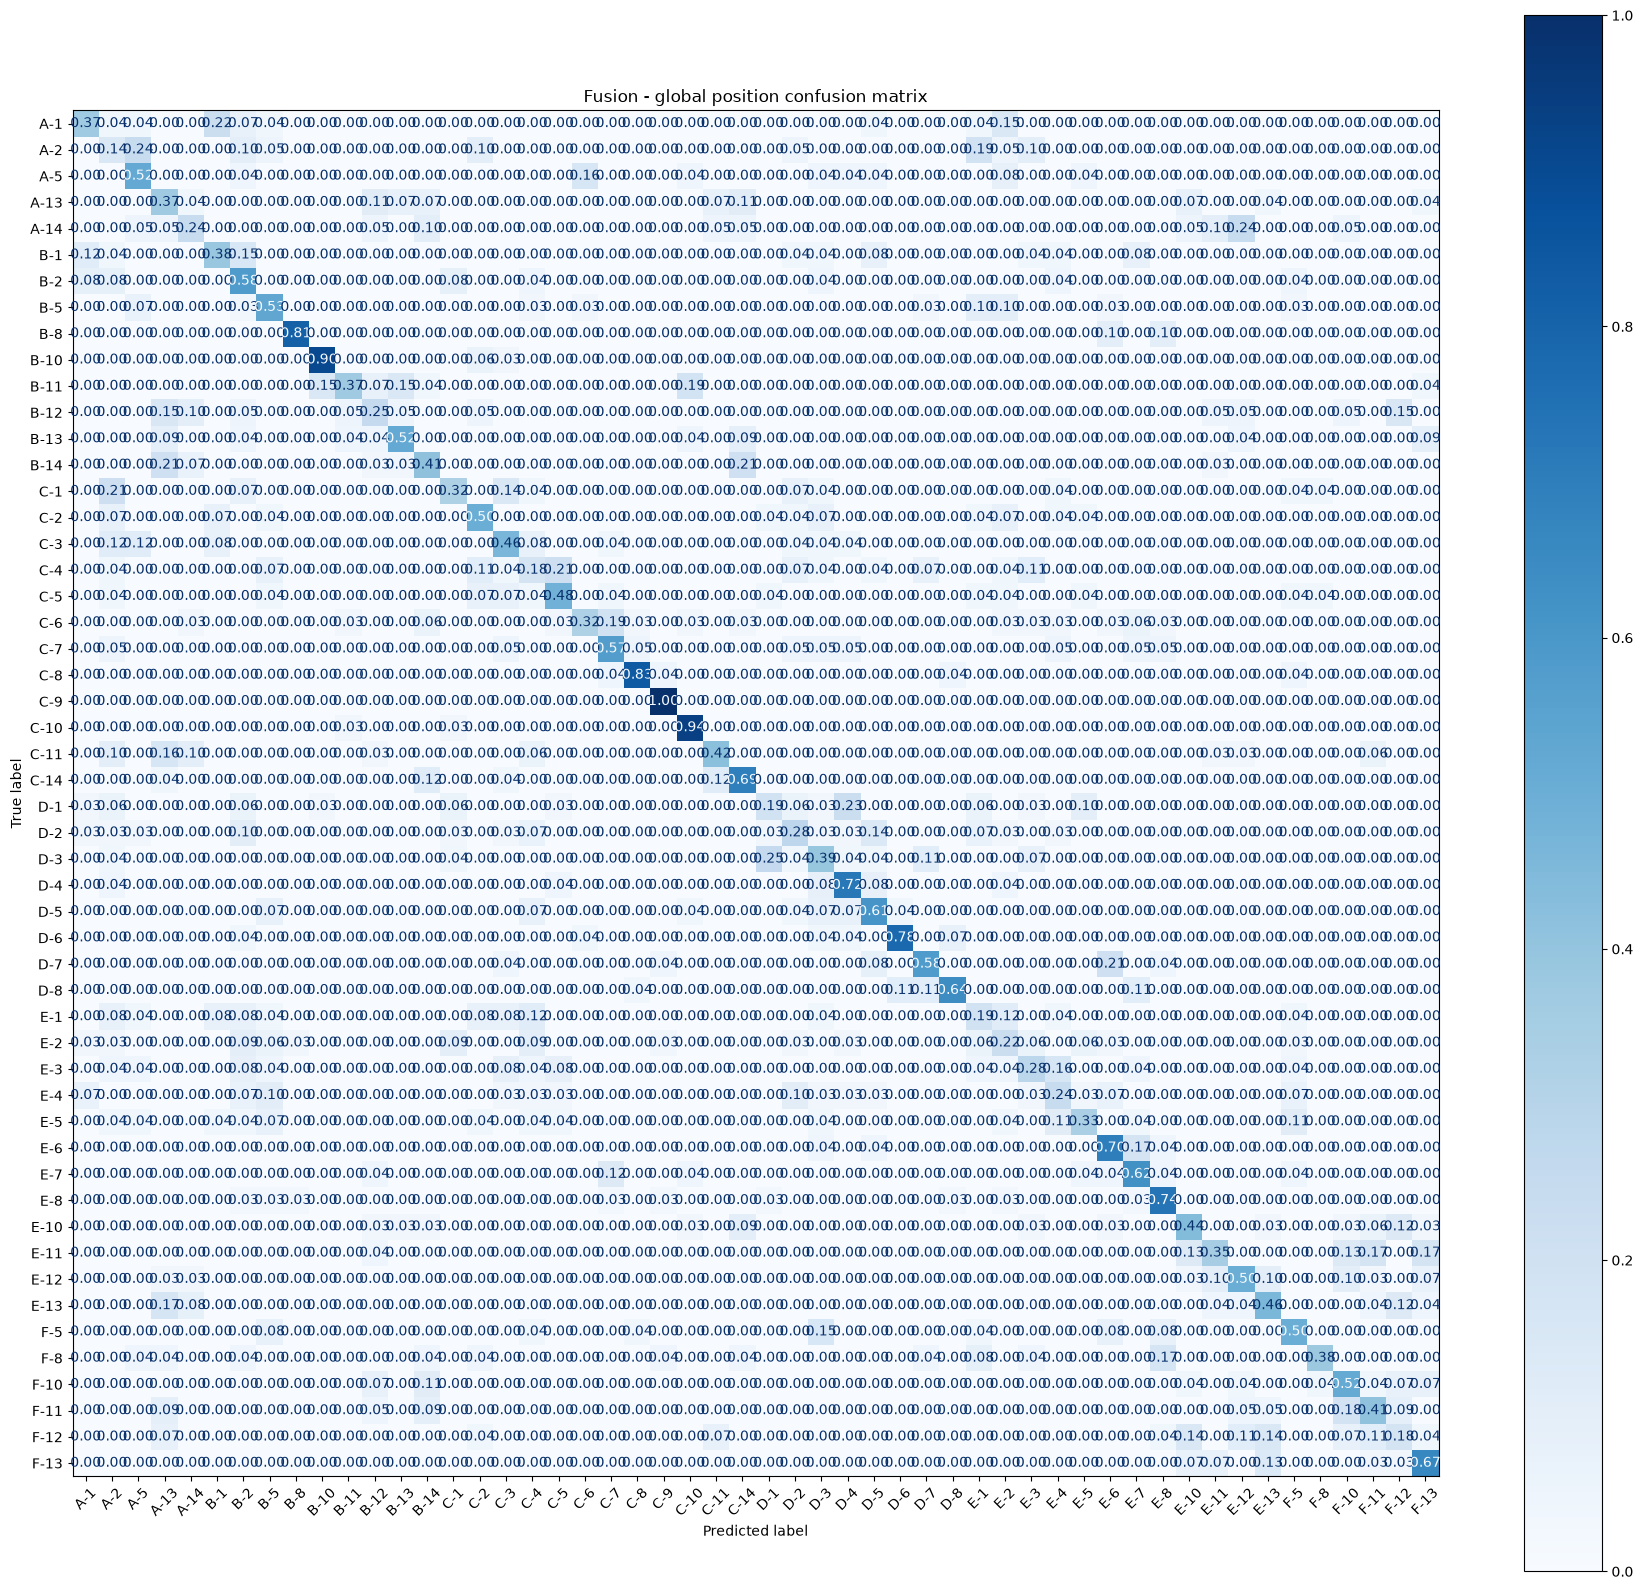

In [12]:
confusion_model, confusion_predictions = best_confusion_predictions(
    all_cnn_predictions,
    cnn_master_table,
    dataset=CONFUSION_DATASET,
    model=ANALYSIS_MODEL,
    split=CONFUSION_SPLIT,
)
print(
    f"Confusion/floor-plan model: {confusion_model} on {CONFUSION_DATASET} "
    f"({CONFUSION_SPLIT}, seed {ANALYSIS_SEED})"
)

figure_stem = (
    f"{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}_"
    f"{CONFUSION_SPLIT}_seed-{ANALYSIS_SEED}"
)
if SHOW_FLOOR_PLAN:
    plot_floor_plan_heatmap(
        confusion_predictions,
        title=(
            f"{CONFUSION_DATASET} / {confusion_model} localization heatmap "
            f"({CONFUSION_SPLIT}, seed {ANALYSIS_SEED})"
        ),
        save_path=analysis_plots_dir / f"floor_plan_{figure_stem}.png",
    )

if SHOW_CONFUSION_MATRICES:
    plot_global_position_confusion_matrix(
        confusion_predictions,
        dataset=CONFUSION_DATASET,
        normalize="true",
        save_path=analysis_plots_dir / f"confusion_{figure_stem}.png",
    )
    if SHOW_PER_ROOM_PLOTS:
        room_plot_dir = analysis_plots_dir / f"confusion_by_room_{figure_stem}"
        plot_position_confusion_by_true_room(
            confusion_predictions,
            dataset=CONFUSION_DATASET,
            normalize="true",
            save_path=room_plot_dir,
        )
